This notebook performs class-balanced grouped cross-validation on the engineered bearing fault dataset.

Objectives:

- Prevent data leakage using Source_File grouping
- Evaluate model generalisation
- Assess Random Forest performance across multiple folds
- Generate robust accuracy statistics

# Import Libraries

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Load Dataset

In [20]:
df = pd.read_csv(
    "phase1_full_dataset.csv"
)

print(df.shape)

(6153, 25)


# Define Features and Labels

In [21]:
X = df.drop(
    columns=[
        "Label",
        "Source_File",
        "RPM"
    ],
    errors="ignore"
)

y = df["Label"]

groups = df["Source_File"]

# Create Class-Balanced Grouped Folds

In [22]:
# Create balanced grouped folds
class_files = {
    0: sorted(df[df["Label"] == 0]["Source_File"].unique()),
    1: sorted(df[df["Label"] == 1]["Source_File"].unique()),
    2: sorted(df[df["Label"] == 2]["Source_File"].unique()),
    3: sorted(df[df["Label"] == 3]["Source_File"].unique())
}

fold_test_files = []

for i in range(4):
    fold_files = [
        class_files[0][i],
        class_files[1][i],
        class_files[2][i],
        class_files[3][i]
    ]
    fold_test_files.append(fold_files)

print("Test files for each fold:")

for i, files in enumerate(fold_test_files, start=1):
    print(f"Fold {i}: {files}")

Test files for each fold:
Fold 1: ['100.mat', '105.mat', '118.mat', '130.mat']
Fold 2: ['97.mat', '106.mat', '119.mat', '131.mat']
Fold 3: ['98.mat', '107.mat', '120.mat', '132.mat']
Fold 4: ['99.mat', '108.mat', '121.mat', '133.mat']


# Run Cross Validation

In [23]:
fold_results = []

for fold, test_files_list in enumerate(
    fold_test_files,
    start=1
):

    print(f"\nFold {fold}")

    test_mask = groups.isin(test_files_list)

    train_idx = df.index[~test_mask]
    test_idx = df.index[test_mask]

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]

    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    train_files = set(groups.loc[train_idx])
    test_files = set(groups.loc[test_idx])

    overlap = train_files.intersection(test_files)

    print("Test Files:", sorted(test_files))
    print("File Overlap:", overlap)

    print("Test Class Distribution:")
    print(y_test.value_counts().sort_index())

    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rf_model.fit(
        X_train,
        y_train
    )

    predictions = rf_model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            labels=[0, 1, 2, 3],
            target_names=[
                "Healthy",
                "Inner Race Fault",
                "Ball Fault",
                "Outer Race Fault"
            ],
            zero_division=0
        )
    )

    fold_results.append(accuracy)


Fold 1
Test Files: ['100.mat', '105.mat', '118.mat', '130.mat']
File Overlap: set()
Test Class Distribution:
Label
0    947
1    235
2    238
3    237
Name: count, dtype: int64
Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

         Healthy       1.00      1.00      1.00       947
Inner Race Fault       1.00      1.00      1.00       235
      Ball Fault       1.00      1.00      1.00       238
Outer Race Fault       1.00      1.00      1.00       237

        accuracy                           1.00      1657
       macro avg       1.00      1.00      1.00      1657
    weighted avg       1.00      1.00      1.00      1657


Fold 2
Test Files: ['106.mat', '119.mat', '131.mat', '97.mat']
File Overlap: set()
Test Class Distribution:
Label
0    475
1    237
2    236
3    238
Name: count, dtype: int64
Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

         Healthy       1.00      1.00      

# Fold Summary

In [24]:
results_df = pd.DataFrame(
{
    "Fold":
        range(
            1,
            len(fold_results)+1
        ),

    "Accuracy":
        fold_results
}
)

results_df

,Fold,Accuracy
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0


# Mean Accuracy

In [25]:
print(
    "Average Accuracy:",
    np.mean(fold_results)
)

print(
    "Standard Deviation:",
    np.std(fold_results)
)

Average Accuracy: 1.0
Standard Deviation: 0.0


# Accuracy Plot

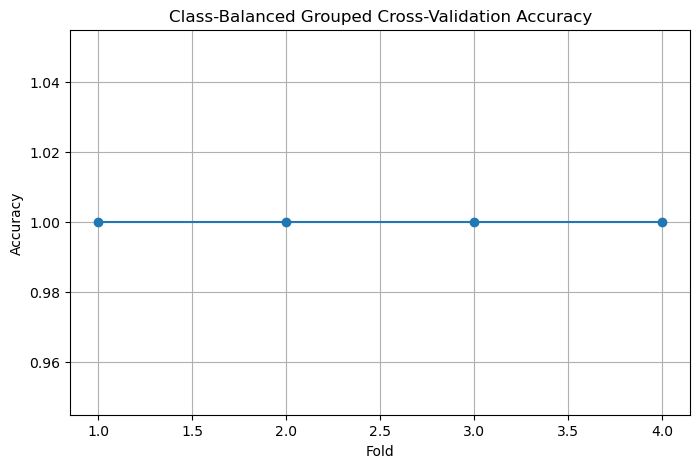

In [28]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,5)
)

plt.plot(
    results_df["Fold"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel(
    "Fold"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Class-Balanced Grouped Cross-Validation Accuracy"
)

plt.grid(True)

plt.show()

# Save Results

In [27]:
results_df.to_csv(
    "groupkfold_results.csv",
    index=False
)

print(
    "Results saved."
)

Results saved.
